### TextCNN

In [3]:
import numpy as np
import re
import itertools
from collections import Counter
from sklearn.model_selection import train_test_split

EMBED_DIM = 4
FILTER_SIZES = [2, 3, 4]
NUM_FILTERS = 2
DROP_RATE = 0.5
EPOCHS = 10
BATCH_SIZE = 8
SEQ_LEN = 80
PADDING_WORD='<PAD/>'

def clean_str(string):
    string = re.sub(r"[^A-Za-z0-9(),!?\'\`]", " ", string)
    string = re.sub(r"\'s", " \'s", string)
    string = re.sub(r"\'ve", " \'ve", string)
    string = re.sub(r"n\'t", " n\'t", string)
    string = re.sub(r"\'re", " \'re", string)
    string = re.sub(r"\'d", " \'d", string)
    string = re.sub(r"\'ll", " \'ll", string)
    string = re.sub(r",", " , ", string)
    string = re.sub(r"!", " ! ", string)
    string = re.sub(r"\(", " \( ", string)
    string = re.sub(r"\)", " \) ", string)
    string = re.sub(r"\?", " \? ", string)
    string = re.sub(r"\s{2,}", " ", string)
    return string.strip().lower()

def load_data_and_labels():
    with open('./data/textCNN_pos', 'r', encoding='latin-1') as f:
        positive_examples = [s.strip() for s in f.readlines()]
    with open('./data/textCNN_neg', 'r', encoding='latin-1') as f:
        negative_examples = [s.strip() for s in f.readlines()]
    
    x_text = positive_examples + negative_examples
    x_text = [clean_str(sent).split(' ') for sent in x_text]
    positive_labels = [[0, 1] for _ in positive_examples]
    negative_labels = [[1, 0] for _ in negative_examples]
    y = np.concatenate([positive_labels, negative_labels], 0)
    return [x_text, y]

def pad_sentences(sentences):
    padded_sentences = []
    for i in range(len(sentences)):
        sentence = sentences[i]
        num_padding = SEQ_LEN - len(sentence)
        new_sentence = sentence + [PADDING_WORD] * num_padding
        padded_sentences.append(new_sentence)
    return padded_sentences

def build_vocab(sentences):
    word_counts = Counter(itertools.chain(*sentences))
    idx2vocab = [x[0] for x in word_counts.most_common()]
    idx2vocab = list(sorted(idx2vocab))
    vocab2idx = {x: i for i, x in enumerate(idx2vocab)}
    return [vocab2idx, idx2vocab]

def build_input_data(sentences, labels, vocab2idx):
    x = np.array([[vocab2idx[word] for word in sentence] for sentence in sentences])
    y = np.array(labels)
    return [x, y]

def load_data():
    sentences, labels = load_data_and_labels()
    sentences_padded = pad_sentences(sentences)
    vocab2idx, idx2vocab = build_vocab(sentences_padded)
    x, y = build_input_data(sentences_padded, labels, vocab2idx)
    return [x, y, vocab2idx, idx2vocab]

x, y, vocab2idx, idx2vocab = load_data()
X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=2024, shuffle=True)
VOCAB_SIZE = len(vocab2idx)
print(X_train.shape, y_train.shape)

(8529, 80) (8529, 2)


In [1]:
import os
# 禁用 Metal 插件，避免加载失败
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["METAL_DEVICE_WRAPPER"] = "0"
os.environ["TF_DISABLE_METAL"] = "1"  # 核心：禁用 Metal 加速

# 再导入 tensorflow
import tensorflow as tf
print(tf.__version__)  # 验证是否能正常导入

2.15.0


Epoch 1/10


2026-03-08 23:12:39.567567: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp_10.


1067/1067 [==============================] - 18s 14ms/step - loss: 0.6888 - accuracy: 0.5398 - val_loss: 0.6767 - val_accuracy: 0.6090
Epoch 2/10
  15/1067 [..............................] - ETA: 8s - loss: 0.6683 - accuracy: 0.6667

/Users/lhc456/miniconda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1067/1067 [==============================] - 12s 11ms/step - loss: 0.6181 - accuracy: 0.6861 - val_loss: 0.6058 - val_accuracy: 0.6779
Epoch 3/10
1067/1067 [==============================] - 13s 12ms/step - loss: 0.4752 - accuracy: 0.7942 - val_loss: 0.5794 - val_accuracy: 0.6807
Epoch 4/10
1067/1067 [==============================] - 13s 12ms/step - loss: 0.3646 - accuracy: 0.8559 - val_loss: 0.5725 - val_accuracy: 0.6985
Epoch 5/10
1067/1067 [==============================] - 11s 10ms/step - loss: 0.2900 - accuracy: 0.8884 - val_loss: 0.5977 - val_accuracy: 0.7046


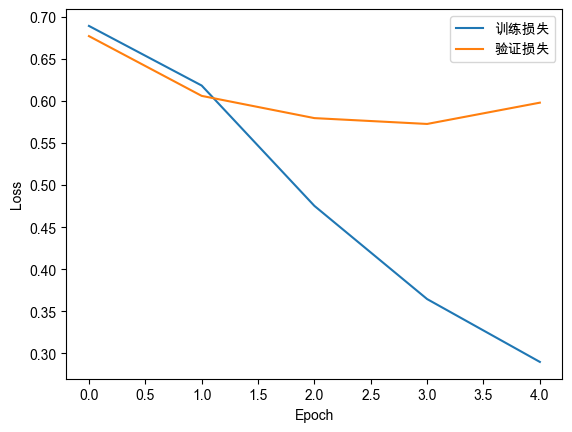

1/1 [==============================] - 0s 101ms/step
['POS', 'NEG']


In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, Conv2D, MaxPool2D
from tensorflow.keras.layers import Reshape, Flatten, Dropout, Concatenate
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

def build_textCNN():
    inputs = Input(shape=(SEQ_LEN,), dtype='int32')
    embedding = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=SEQ_LEN)(inputs)
    reshape = Reshape((SEQ_LEN, EMBED_DIM, 1))(embedding)
    
    conv_pool = []
    for size in FILTER_SIZES:
        conv = Conv2D(NUM_FILTERS, kernel_size=(size, EMBED_DIM), padding='valid', kernel_initializer='normal', activation='relu')(reshape)
        maxpool = MaxPool2D(pool_size=(SEQ_LEN - size + 1, 1), strides=(1, 1), padding='valid')(conv)
        conv_pool.append(maxpool)
    concatenated_tensor = Concatenate(axis=1)(conv_pool)
    flatten = Flatten()(concatenated_tensor)
    dropout = Dropout(DROP_RATE)(flatten)
    output = Dense(units=2, activation='softmax')(dropout)
    model = Model(inputs=inputs, outputs=output)
    return model

def train():
    model = build_textCNN()
    checkpoint = ModelCheckpoint('./model/textcnn.{epoch:03d}-{val_accuracy:.4f}.hdf5', monitor='val_accuracy', save_best_only=True, mode='auto')
    adam = Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
    model.compile(optimizer=adam, loss='binary_crossentropy', metrics=['accuracy'])
    # 设置EarlyStopping回调函数: 当模型的指标在连续patience个训练周期内没有改善时，就会触发提前停止训练
    early_stopping = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)
    model.fit(X_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS, callbacks=[checkpoint, early_stopping], validation_data=(X_val, y_val))
    return model

def plot(model):
    # 显示中文
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
    cur_history = model.history.history
    plt.plot(cur_history['loss'], label='训练损失')
    plt.plot(cur_history['val_loss'], label='验证损失')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


model = train()
plot(model)

test_data = ['today is a good day', 'today is a bad day']
test_data = [clean_str(sent).split(' ') for sent in test_data]
test_data = [sent + [PADDING_WORD] * (SEQ_LEN - len(sent)) for sent in test_data]
test_data = np.array([[vocab2idx[word] for word in sentence] for sentence in test_data])
res = tf.argmax(model.predict(test_data), axis=-1).numpy().tolist()
label2word = {1: 'POS', 0: 'NEG'}
print([label2word[x] for x in res])

### fastText

In [5]:
# !pip install fasttext
# !pip install gensim

import fasttext
import random
# from gensim.models import FastText
def data_prepare():
    with open('./data/textCNN_pos', 'r', encoding='latin-1') as fp:
        positive_examples = [clean_str(x.strip()) for x in fp.readlines()]
    with open('./data/textCNN_neg', 'r', encoding='latin-1') as fn:
        negative_examples = [clean_str(x.strip()) for x in fn.readlines()]
    data = ['__label__pos ' + sample for sample in positive_examples] + ['__label__neg ' + sample for sample in negative_examples]
    random.shuffle(data)
    with open('./data/fasttext_data', 'w') as fw:
        fw.write('\n'.join(data))
    return './data/fasttext_data'
    
# 设置参数
epochs = 10
lr = 1
word_ngrams = 2
dim = 100
data_file = data_prepare()
# 训练模型
model = fasttext.train_supervised(input=data_file, epoch=epochs, lr=lr, wordNgrams=word_ngrams, dim=dim)
# 保存模型
model.save_model('./model/fasttext_model.bin')

# 加载模型
# model = fasttext.load_model('./model/fasttext_model.bin')
# 进行预测
texts = ['today is a good day', 'today is a bad day']
for text in texts:
    prediction = model.predict(text)
    # 输出预测结果
    print('----', text)
    print('Prediction:', prediction[0][0])
    print('Probability:', prediction[1][0])

Read 0M words
Number of words:  18766
Number of labels: 2


---- today is a good day
Prediction: __label__pos
Probability: 1.0000100135803223
---- today is a bad day
Prediction: __label__neg
Probability: 0.7987720966339111


Progress: 100.0% words/sec/thread: 2054253 lr:  0.000000 avg.loss:  0.126429 ETA:   0h 0m 0s


### Bert

/Users/lhc456/miniconda/lib/python3.10/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Epoch 1/10
1067/1067 [==============================] - 53s 44ms/step - loss: 0.7003 - accuracy: 0.5636 - val_loss: 0.6535 - val_accuracy: 0.6043
Epoch 2/10
1067/1067 [==============================] - 43s 40ms/step - loss: 0.5869 - accuracy: 0.6986 - val_loss: 0.6239 - val_accuracy: 0.6639
Epoch 3/10
1067/1067 [==============================] - 44s 41ms/step - loss: 0.4942 - accuracy: 0.7725 - val_loss: 0.6359 - val_accuracy: 0.6540


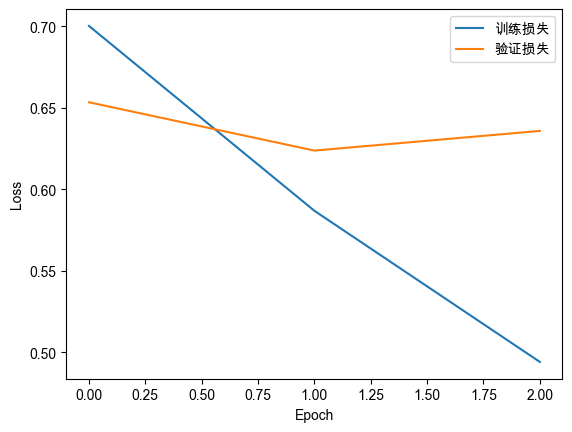

1/1 [==============================] - 1s 657ms/step
['POS', 'NEG']


In [8]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from keras_bert import load_trained_model_from_checkpoint, Tokenizer
from keras.layers import Dense, Input, Lambda
from keras.models import Model
import matplotlib.pyplot as plt

# 数据继续用第一个cell里的 TextCNN 数据

def get_bert():
    # 设置预训练模型的路径
    pretrained_path = './model/uncased_L-2_H-128_A-2'
    config_path = f'{pretrained_path}/bert_config.json'
    checkpoint_path = f'{pretrained_path}/bert_model.ckpt'
    vocab_path = f'{pretrained_path}/vocab.txt'
    # 加载预训练模型 Tensorflow(>=2.12)
    model = load_trained_model_from_checkpoint(config_path, checkpoint_path, trainable=True, seq_len=SEQ_LEN)
    return model

def build_classify_base_bert():
    inputs = Input(shape=(SEQ_LEN,), name='input_ids', dtype='int32')
    
    pretrained_model = get_bert()
    x = pretrained_model([inputs, tf.zeros_like(inputs)])  # 第二个参数 segment_ids
    x = Lambda(lambda x: x[:, 0])(x)
    # 添加分类层
    output = Dense(2, activation='softmax')(x)
    model = Model(inputs, output)

    # 编译模型
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

def train():
    model = build_classify_base_bert()
    # 设置EarlyStopping回调函数: 当模型的指标在连续patience个训练周期内没有改善时，就会触发提前停止训练
    early_stopping = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)
    # 训练模型
    model.fit(X_train, y_train, validation_data=(X_val, y_val), 
              epochs=10, batch_size=8, callbacks=[early_stopping])

    checkpoint = tf.train.Checkpoint(model=model)
    checkpoint.save('model/bert_classify/bert_classify.ckpt')
    return model
    
def plot(model):
    # 显示中文
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
    cur_history = model.history.history
    plt.plot(cur_history['loss'], label='训练损失')
    plt.plot(cur_history['val_loss'], label='验证损失')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def predict():
    cur_model = build_classify_base_bert()
    checkpoint = tf.train.Checkpoint(model=cur_model)
    checkpoint.restore('model/bert_classify/bert_classify.ckpt-1')
    
    test_data = ['today is a good day', 'today is a bad day']
    test_data = [clean_str(sent).split(' ') for sent in test_data]
    test_data = [sent + [PADDING_WORD] * (SEQ_LEN - len(sent)) for sent in test_data]
    test_data = np.array([[vocab2idx[word] for word in sentence] for sentence in test_data])
    res = tf.argmax(cur_model.predict(test_data), axis=-1).numpy().tolist()
    label2word = {1: 'POS', 0: 'NEG'}
    print([label2word[x] for x in res])

model = train()
plot(model)
predict()

### 分布式部署

In [ ]:
# 部署

from flask import Flask, request
import argparse
import fasttext

app = Flask(__name__)

@app.route('/')
def fasttext_req():
    param = request.args.get('p')
    print('param:' + param)
    return load_model(param)

def load_model(text):
    prediction = model.predict(text)
    return f'this sentence is {prediction[0][0].split("_")[-1]} with score = {round(prediction[1][0], 5)}'

model = fasttext.load_model('/Users/wenyun_kang/forLong/model/fasttext_model.bin')
if __name__ == '__main__':
    parser = argparse.ArgumentParser(description='Description of your script')
    parser.add_argument('arg1', type=int, help='port number')
    args = parser.parse_args()
    print(args)
    app.run(debug=True, port=args.arg1)

    
# python test_flask.py 5000

In [ ]:
# 请求服务

import requests

def req(text_set):
    for t in text_set:
        url = get_hash_url(t['id']) + t['text']
        print(url)
        res_text = requests.get(url).text
        t['res'] = res_text
    return text_set

def get_hash_url(key):
    key_hash = hash(key)
    return url_list[key_hash % len(url_list)]

url_list = ['http://127.0.0.1:5000?p=',
            'http://127.0.0.1:5001?p=',
            'http://127.0.0.1:5002?p=',
            'http://127.0.0.1:5003?p=']

if __name__ == '__main__':
    p1 = {'id': 100, 'text': 'today is a good day'}
    p2 = {'id': 101, 'text': 'today is a bad day'}
    p3 = {'id': 102, 'text': 'you are very kindly'}
    p4 = {'id': 103, 'text': 'i am felling a little sad'}
    p5 = {'id': 104, 'text': 'the weather is raining'}
    p6 = {'id': 105, 'text': 'it is monday'}
    t_set = [p1, p2, p3, p4, p5, p6]
    print(req(t_set))

### kmeans 聚类

In [ ]:
# threadpoolctl 需要 3.1 版本
!pip install threadpoolctl==3.1.0
# !pip install scikit-learn
!pip list | grep threadpoolctl

/Users/wenyun_kang/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)



 cluster聚类数量：
0    6834
3    3546
2    3013
1    1851
4     878
Name: count, dtype: int64

 cluster聚类中心：
不亚于	房产证	3700	结合实际	understand	

 类别为1的数据: 
考生	考试	高考	信息	教育	时间	报名	工作	记者	情况	

 most_similar top10 word of 房产证 are: 
('户口本', 0.9664406776428223)
('可持', 0.9656814932823181)
('设区', 0.9632944464683533)
('查验', 0.9627969264984131)
('需持', 0.9616550207138062)
('照像', 0.9604271054267883)
('副证', 0.9575083255767822)
('要持', 0.9568671584129333)
('开具', 0.9565741419792175)
('未办理', 0.9540666341781616)


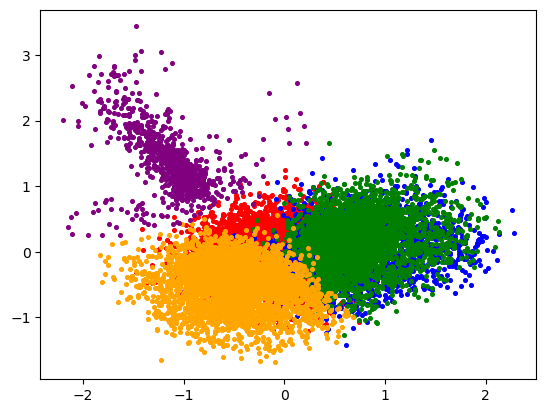

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, accuracy_score, normalized_mutual_info_score, rand_score
from sklearn.decomposition import PCA
from gensim.models import Word2Vec
from joblib import dump, load
from sklearn.metrics import pairwise_distances_argmin

def get_word2vec():
    # 加载模型
    w2v_model = Word2Vec.load('./model/w2v_skip_gram.model')
    # 提取词向量
    # word_vectors = model.wv
    words = pd.DataFrame(w2v_model.wv.key_to_index.items(), columns=['word', 'idx'])
    return w2v_model, words['word']

def build_kmeans():
    kmeans_model = KMeans(n_clusters=k)
    # 训练模型
    kmeans_model.fit(word_vectors)
    dump(kmeans_model, './model/kmeans.joblib')
    return kmeans_model
    
def predict():
    kmeans_model = load('./model/kmeans.joblib')
    # 预测全部数据
    return kmeans_model.predict(word_vectors)

def res_check():
    quantity = pd.Series(y_pred).value_counts()
    print(f'\n cluster聚类数量：\n{quantity}')
    
    centroid = kmeans_model.cluster_centers_
    labels_random = pairwise_distances_argmin(centroid, word_vectors)
    print('\n cluster聚类中心：')
    for index in labels_random:
        print(f'{words[index]}\t', end='')
        
def print_similar(word):
    print(f'\n\n most_similar top10 word of {word} are: ')
    for item in w2v_model.wv.most_similar(positive=[word], topn=10):
        print(item)
    
def print_word(n_cate):
    res = words[(y_pred == n_cate)]
    count = 0
    print(f'\n\n 类别为{n_cate}的数据: ')
    for word in res:
        print(f'{word}\t',end='')
        count = count + 1
        if(count % 10 == 0):
            break

def plot():
    dataset = word_vectors.tolist()
    if len(dataset[0]) > 2:
        dataset = PCA(n_components=2).fit_transform(dataset)  # 如果属性数量大于2，降维
    colors = np.array(['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'beige', 'hotpink', '#88c999'])
    # 循换打印k个簇，每个簇使用不同的颜色
    for i in range(k):
        plt.scatter(dataset[np.nonzero(y_pred == i), 0], dataset[np.nonzero(y_pred == i), 1], c=colors[i], s=7)
    plt.show()

k = 5
w2v_model, words = get_word2vec()
word_vectors = w2v_model.wv.vectors
kmeans_model = build_kmeans()
y_pred = predict()

res_check()
print_word(1)
print_similar('房产证')
plot()